<div style="display:none">
$$
\def\rvar#1{\mathrm{#1}}
\def\rvec#1{\mathbf{#1}}
\def\vec#1{\boldsymbol{#1}}
\def\tens#1{\boldsymbol{\mathsf{#1}}}
\def\tensel#1{\mathsf{#1}}
\def\st#1{\mathcal{#1}}
\def\diag#1{\mathrm{diag}(\vec{#1})}
$$
</div>

In [1]:
# Setup for Google Colab
import sys, os
if 'google.colab' in sys.modules:
    if not os.path.exists('dl_course'):
        !git clone -q --depth 1 https://github.com/konstantin-schekotihin/dl_course.git
    %cd -q /content/dl_course/02_ML
    !pip install -q torch-geometric wandb

# some initialization stuff
%run ../init.py
%matplotlib inline
import statsmodels.api as sm
import scipy.stats as stats

def annotate(x, y, **kws):
    (r, p) = stats.pearsonr(x, y)
    ax = plt.gca()
    ax.annotate("r = {:.2f}, p = {:.3f} ".format(r, p),
                xy=(.1, 1), xycoords=ax.transAxes)

def plot_residuals(f, pred, resp, show=False):
    est = f(pred.reshape(-1,1))
    if show:
        rss = np.sum(np.power(resp-est, 2))
        tss = np.sum(np.power(resp-np.average(resp), 2))
        print("TSS = {:.3f} - total sum of squares - squared error of an average predictor".format(tss))
        print("RSS = {:.3f} - residual sum of squares".format(rss))
        print("ESS = TSS - RSS =  {:.3f} - {:.3f} = {:.3f} - explained sum of squares".format(tss, rss, tss - rss))
        print("MSE = {:.3f} - mean squared error".format(rss/est.shape[0]))
        print("MAE = {:.3f} - mean absolute error".format(np.sum(np.abs(resp-est))/est.shape[0]))
    
    l = np.linspace(0, 300, num=1000).reshape(-1,1)
    
    plt.figure(figsize=(10,10))
    plt.plot([pred, pred], [resp, est], 'bo--')
    plt.plot(pred, est, 'ro')
    plt.plot(l, f(l), 'r')
    plt.show();

<IPython.core.display.Latex object>

# Linear regression

## Linear regression
- "Regression" -- return to a former state, i.e. from data points to a function that generated them
- *Linear regression* is a quite "simple" approach: simple in the sense of suggested model
- The model *assumes* that the response variable $\rvar{y}$ is dependent **linearly** on $\rvar{x}_1, \dots, \rvar{x}_n$ independent random variables

- The *true dependency* between $\rvar{y}$ and $\rvar{x}_1, \dots, \rvar{x}_n$ is almost **never** linear
- However, *in practice* this simplification is very useful and makes the problem of finding a regression easy to compute

## Example: Advertisement
- Advertising data set: sales of some product in 200 different markets, along with advertising budgets for the product in each of those
markets for three different media: TV, radio, and newspaper.
  + *TV*, *newspaper* and *radio* are independent variables, aka predictors, covariates, input variables, or features
  + *sales* is a dependent variable that we want to predict, aka response, variate, output variable, or labels


In [2]:
adv = pd.read_csv('data/Advertising.csv')
adv = adv.drop(adv.columns[0], axis=1) 
adv.head(5)

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [3]:
adv.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


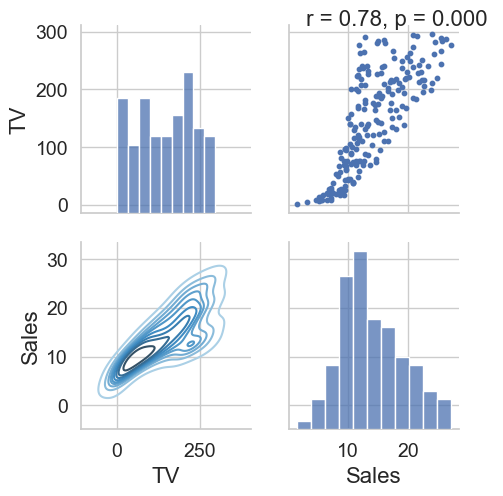

In [4]:
g = sns.PairGrid(adv[["TV","Sales"]])
g.map_upper(plt.scatter, s=10)
g.map_upper(annotate)
g.map_diag(sns.histplot, kde=False)
g.map_lower(sns.kdeplot, cmap="Blues_d");

## Research questions

- If we invest more in advertisement, will it make any difference for the sales? Is there any relationship between them?
- If the relationship exists: is it positive or negative? How strong is it?
- Is the relationship linear?
- Which of the three media TV, radio or newspapers contribute to sales?
- Are there relations between the advertising media? 
    * For example, advertisement on TV and radio has stronger influence on sales, than only on TV
- How accurately can we predict future sales?

## Simple linear regression
- Assume a simple linear model in which the response variable $\rvar{y}$ depends only on one feature $\rvar{x}$
\begin{equation*}
\rvar{y}=w_0 + w_1 \rvar{x} + \epsilon
\end{equation*}
- $w_0$ determines the *intercept* and $w_1$ the slope of the line
- These parameters (coefficients) of the model are unknown and must be found
- $\epsilon$ is the random *error* term, which captures all we ignored in the linear model
\begin{equation*}
\rvar{sales} \approx w_0 + w_1 \rvar{TV}
\end{equation*}

- Given estimates of parameters $\hat{w_0}$ and $\hat{w_1}$ computed by fitting algorithm we can compute the estimate
\begin{equation*}
\widehat{\rvar{sales}} = \hat{w_0} + \hat{w_1} \rvar{TV} 
\end{equation*}

- In matrix form
\begin{equation*}
\widehat{\vec{sales}} = \vec{X} \hat{\vec{w}} = \begin{bmatrix}\vec{1}, \vec{tv}\end{bmatrix} \begin{bmatrix}\hat{w_0} \\ \hat{w_1} \end{bmatrix} 
\end{equation*}
where $\vec{1}$ and $\vec{tv}$ are column vectors comprising ones and $\rvar{TV}$ observations

In [5]:
def residuals(w0=0, w1=0, l=0, u=200, show=False):
    f = lambda x: np.dot(np.hstack( (np.ones((x.shape[0],1)), x) ), [[w0], [w1]]).ravel()
    tv = adv.TV[l:u].to_numpy()
    sales = adv.Sales[l:u].to_numpy()
    plot_residuals(f, tv, sales, show)

In [6]:
interact(residuals, w0=(0,10,1), w1=(0.01,0.1,0.01), l=(0,200,10), u=(0,200,10));

interactive(children=(IntSlider(value=0, description='w0', max=10), FloatSlider(value=0.01, description='w1', …

## Measures

- *Total sum of squares* (TSS) indicates error of an average prediction $\lVert \vec{y} - \overline{y}\rVert^2_2$, where $\overline{y}$ is an average of all target values
    - $\overline{sales}$ is an average sales value recorded in the dataset
- *Residual sum of squares* (RSS) $\lVert \vec{y} - \hat{\vec{y}}\rVert^2_2$, where $\hat{\vec{y}}$ is a vector of values predicted by the model
    - $\widehat{\vec{sales}}$ all sales values predicted by the model $\widehat{\vec{sales}} = \hat{w}_0 + \hat{w}_1\mathit{TV}$
    - Vector norms can be formulated as follows ${\lVert\vec{x}\rVert_{p}:=\left(\sum _{i=1}^{n}\left|x_{i}\right|^{p}\right)^{1/p}}$
- *Explained Sum of Squares* (ESS) is defined as $\mathit{TSS} - \mathit{RSS}$ and indicates by how much our model does better than an average predictor
- *Mean Squared Error* (MSE) is usually defined as $\frac{1}{n}\mathit{RSS}$
    - In case of regression $\mathit{df} = n - p - 1$ is often used to obtain an unbiased estimate of a variance
- *Mean Absolute Error* (MAE) corresponds to $\frac{1}{n}\lVert \vec{y} - \hat{\vec{y}}\rVert_1$

In [7]:
interact(residuals, w0=(0,10,1), w1=(0.01,0.1,0.01), l=(0,200,10), u=(0,200,10), show=True);

interactive(children=(IntSlider(value=0, description='w0', max=10), FloatSlider(value=0.01, description='w1', …

## Parameter estimation
- A **residual** is the difference between the real and estimated values of the response variable
- Formally, if $\hat{y_i} = \hat{w_0} + \hat{w_1}x_i$ is a prediction for $\rvar{y}$ based on $x_i$ value of $\rvar{x}$, then $e_i=y_i-\hat{y_i}$
- The **residual sum of squares** (RSS) is a common choice to measure the estimation error
    - The latter is also called objective, energy, or loss function, which we are going to optimize
- The **least squares** approach chooses such values $\hat{w_0}$ and $\hat{w_1}$ of model parameters which *minimize* RSS

## Example: Advertising

- Red line shows the least squares fit for the regression of $\rvar{sales}$ onto $\rvar{TV}$
- Blue segments represent residuals between input data (blue dots) and the least squares line, which approximates the regression line ($\epsilon$)

Parameters: w_0 = 7.032593549127689, w_1 = [0.04753664]


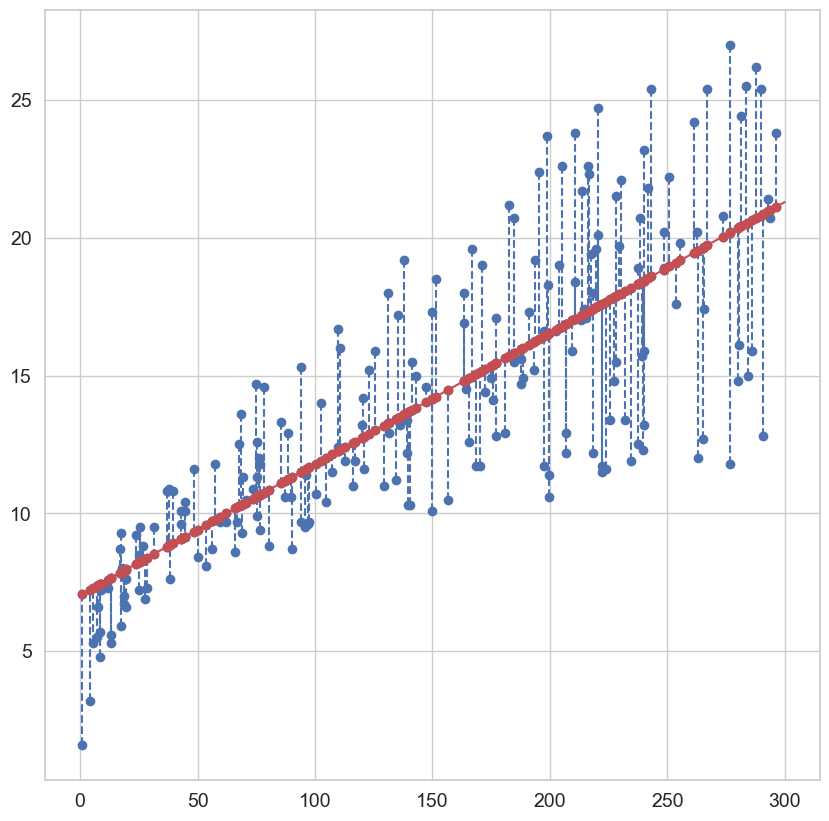

In [8]:
from sklearn.linear_model import LinearRegression

tv = adv.TV[0:200].to_numpy()
sales = adv.Sales[0:200].to_numpy()
lin_model = LinearRegression().fit(tv.reshape(-1,1), sales)
print("Parameters: w_0 = {}, w_1 = {}".format(lin_model.intercept_, lin_model.coef_))
plot_residuals(lin_model.predict, tv, sales)

## Evaluation of a model fit

<div class="myalert">
We want to quantify the extent to which the model fits the data
</div>

In [9]:
lm = sm.OLS(adv.Sales, sm.add_constant(adv.TV))
print(lm.fit().summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Tue, 05 May 2026   Prob (F-statistic):           1.47e-42
Time:                        11:58:44   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0326      0.458     15.360      0.0

## Standard error

- The **standard error** (SE) of an estimator reflects how it varies under repeated sampling
- For linear regression, standard errors of a coefficient estimate $\hat{w_i}$ can be used to determine confidence intervals comprising the real values of a coefficient $w_i$
- *95\% confidence interval* comprising the real value of estimated coefficient is determined by a formula $\hat{w_i}\pm 2*\mathit{SE}(\hat{w_i})$

- In the advertisement example: 
  - estimates of coefficients $w_0 = 7.0326$ (const) and $w_1 = 0.0475$ (TV) are very large relative to their standard errors, $0.458$ and $0.003$, resp.
  - the interval $[6.130, 7.935]$ with 95% comprises the real value of $w_0$ and the interval $[0.042, 0.053]$ - the real value of $w_1$

## Significance of coefficients

- Standard errors can be used to test whether one of the two hypothesis hold:
  - $H_0$ (null hypothesis): There is no relationship between the predictor and the response
  - $H_1$ (alternative) : There is some relationship between them
- If the null hypothesis is accepted, then we can set $w_1 = 0$, in our example
- *t-statistic* \begin{equation*} t=\frac{\hat w_1}{\mathit{SE}(\hat w_1)} \end{equation*} measures the number of standard deviations that $\hat w_1$ is away from 0

- **p-value**  is defined as $2\cdot p(T\geq|t|)$ - probability of observing any value $T \geq |t|$ assuming $w_i=0$, where  $T$ follows Student t-distribution with $n-2$ degrees of freedom, where $n$ is the number of observations
  - allows to infer if there is an association between the predictor and the response
  - If the p-value is small enough, e.g., $<0.05$, we declare that a relationship between the predictor and the response exists
  - In the advertisement case, a small *p-value* indicates that $w_1 \neq 0$ and there is a connection between $\mathit{sales}$ and $\mathit{TV}$

## Residual standard error

- **Residual Standard Error** (RSE) -- estimate of the standard deviation of $\epsilon$ in the model, e.g. $y=w_0 + w_1 x + \epsilon$
$$ \mathit{RSE} = \sqrt{\frac{\mathit{RSS}}{n-p-1}} $$ where $p$ is the number of independent variables in the model
- Indicates the *average deviation* of response from the true regression line, which we do not know
- E.g., in the advertisement case RSE shows that the actual sales deviate from the true regression line by appr. $3.259$
- Widely considered as an absolute measure of the lack of fit of the model to the data
- Not always clear what constitutes a good RSE

## R-squared statistics
- $R^2$ statistics is a measure alternative to RSE
$$R^2=1-\frac{\mathit{RSS}}{\mathit{TSS}} ~~~~ \text{where} ~~~~ \mathit{TSS}=\sum(y-\overline{y})^2$$ 
- Indicates *proportion of the variance explained*, has values in the interval $[-\infty,1]$
- Values close to $1$ indicate that a large portion of the variability in $\rvar{y}$ has been explained using $X$
- Determining which value of $R^2$ is good for a particular application is quite challenging
    + In engineering, where the nature of a process is known values far below $1$ mean that there is a problem with measurements
    + In medicine or psychology values above $0.2$ can be questionable
- $R^2$ has a sense similar to that of correlation and for simple linear regression they have the same value

### Polynomials

- Linear regression can be used to fit polynomial models
- Consider a case when we would like to fit a polynomial of degree 3 of one variable

$$ y = w_0 + w_1 x_1 + w_2 x_1^2 + w_3 x_1^3 $$

- The least squares method does not allow to work with powers, e.g., for $\mathit{RSS}=\lVert \vec{y} - \hat{\vec{y}}\rVert^2_2$, where $\hat{\vec{y}} = \vec{X}\hat{\vec{w}}$


\begin{align*}
\lVert \vec{y} - \vec{\hat{w}}\vec{X}\rVert^2_2 \\
\end{align*}

## Multiple factors

- Let's fit linear regression for individual predictors

## Example: Advertisement

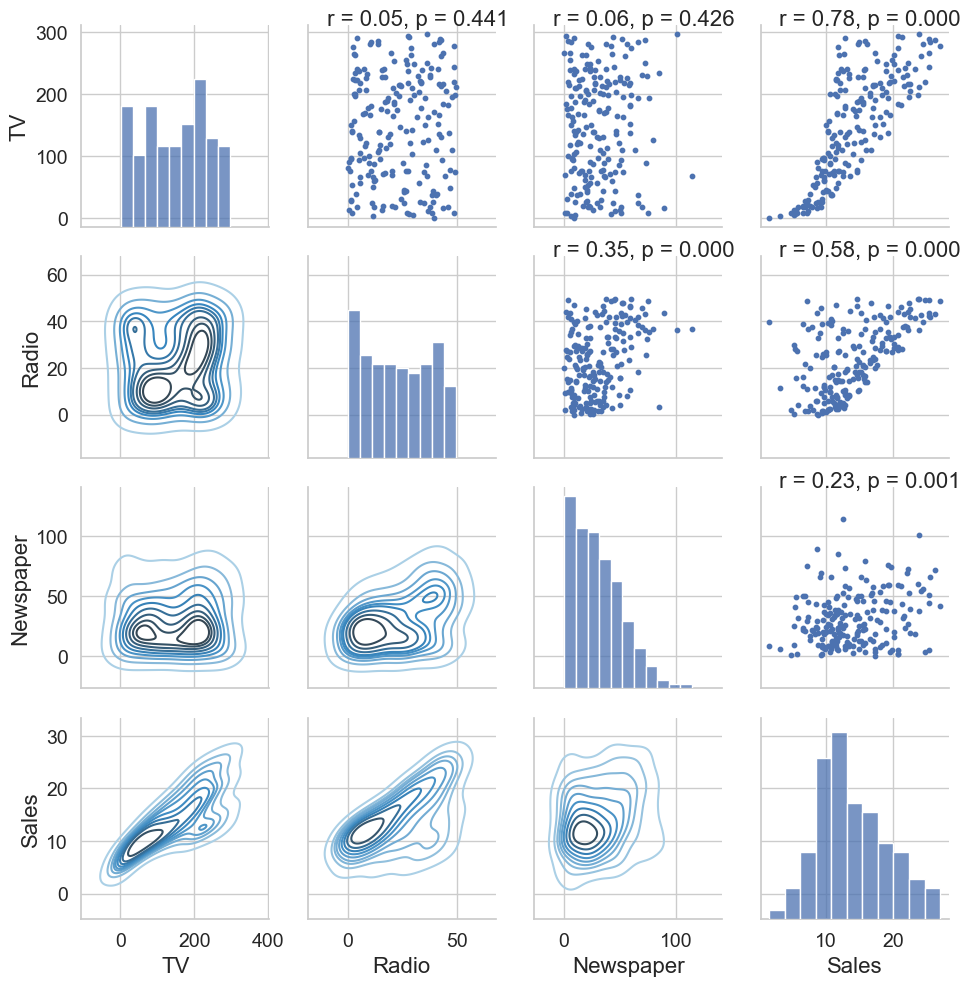

In [10]:
g = sns.PairGrid(adv)
g.map_upper(annotate)
g.map_upper(plt.scatter, s=10)
g.map_diag(sns.histplot, kde=False)
g.map_lower(sns.kdeplot, cmap="Blues_d");

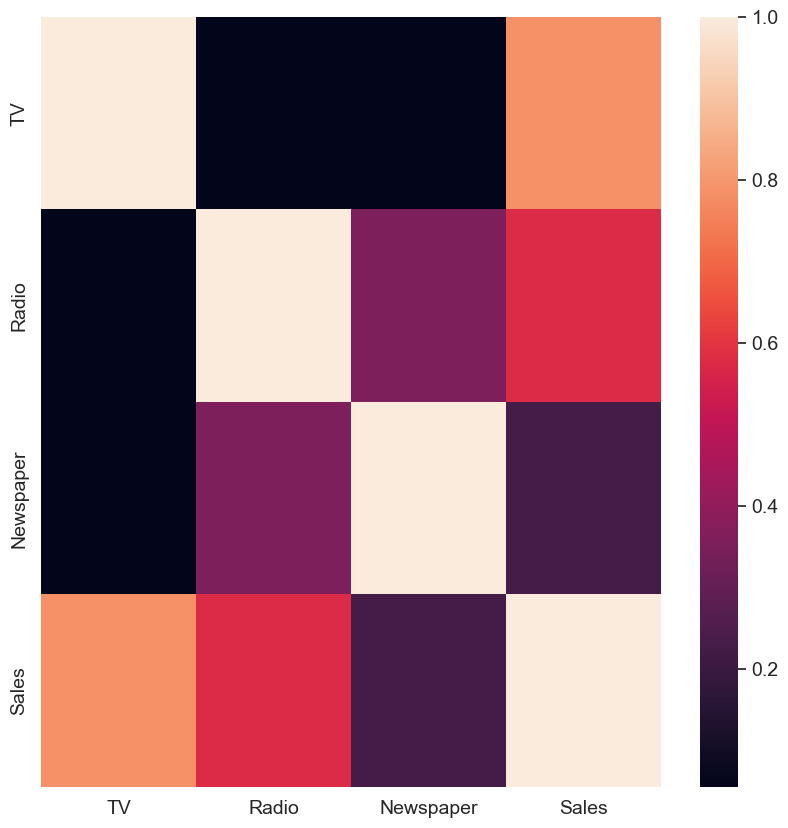

In [11]:
sns.heatmap(adv.corr());

In [12]:
lm = LinearRegression().fit(adv.Radio.values.reshape(-1,1), adv.Sales)
print("Radio: {}".format(lm.coef_))
lm = LinearRegression().fit(adv.TV.values.reshape(-1,1), adv.Sales)
print("TV: {}".format(lm.coef_))
lm = LinearRegression().fit(adv.Newspaper.values.reshape(-1,1), adv.Sales)
print("Newspaper: {}".format(lm.coef_))

Radio: [0.20249578]
TV: [0.04753664]
Newspaper: [0.0546931]


- Increase of advertisement budget by 1000 increases sales by appr.
    + Radio:  203 items
    + TV: 47 items
    + Newspaper: 55 items
- Are there any synergies between these features?

## Multiple linear regression

- The multiple regression model is defined as follows
$$\vec{y}=\vec{X}\;\vec{w} + \epsilon$$
- the first column of $\vec{X}$ is 1 - used to encode the intercept
- $w_i \in \vec{w}$ - average influence of $\rvar{x}_i$ on $\rvar{y}$, when all other features are fixed
- The fitting of the model is done by same least squares approach minimizing the sum of squared residuals
- In advertising example
$$\rvar{sales}=w_0 + w_1 \rvar{TV} + w_2 \rvar{Radio} + w_3 \rvar{Newspaper} + \epsilon$$

In [27]:
X = adv.iloc[:,[0,1]]
print(X)
X = (X - X.mean())/X.std()
print(X)
lm = sm.OLS(adv.Sales, sm.add_constant(X))
print(lm.fit().summary())

        TV  Radio
0    230.1   37.8
1     44.5   39.3
2     17.2   45.9
3    151.5   41.3
4    180.8   10.8
..     ...    ...
195   38.2    3.7
196   94.2    4.9
197  177.0    9.3
198  283.6   42.0
199  232.1    8.6

[200 rows x 2 columns]
           TV     Radio
0    0.967425  0.979066
1   -1.194379  1.080097
2   -1.512360  1.524637
3    0.051919  1.214806
4    0.393196 -0.839507
..        ...       ...
195 -1.267759 -1.317724
196 -0.615491 -1.236899
197  0.348934 -0.940539
198  1.590574  1.261955
199  0.990720 -0.987687

[200 rows x 2 columns]
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     859.6
Date:                Tue, 12 May 2026   Prob (F-statistic):           4.83e-98
Time:                        12:24:20   Log-Likelihoo

## Analysis of a model fit
- Coefficients for $\mathit{TV}$ and $\mathit{Radio}$ are quite similar to the ones of simple linear regression
- Coefficient of $\mathit{Newspaper}$ dropped from $0.055$ to almost 0
- Its *p-value* is no longer significant, so we can assume that there is no relationship between $\mathit{Newspaper}$ and $\mathit{Sales}$ 
- Correlation $r_{RN}=0.35$ which means that the company tends to increase  "radio" and "newspaper" spendings simultaneously
- Consequently, increase of sales due to "radio" is captured by simple linear regression examining "sales" versus "newspaper"
- Evaluation of the model follows that of simple linear regression wrt. residual standard error and $R^2$
- Low p-value in our example indicates that at least one of the media is a cause of the increased sales

## F-statistic

- In linear regression we considered t-statistic to identify if there is a relationship between one predictor $X$ and the response $\rvar{y}$
- For multiple linear regression we might want to test which the following hypotheses holds
\begin{equation*}
H_0 \; : \; w_1 = w_2 = \dots = w_p = 0 \\
H_a \; : \; \text{some }  w_i \neq 0 
\end{equation*}
- This test is done using *F-statistic*
\begin{equation*}
f=\frac{(\mathit{TSS}-\mathit{RSS})/p}{\mathit{RSS}/(n-p-1)}
\end{equation*}


- If there is no relationship between the response and the predictors, then $P(F \leq f)$ should be close to $1$, where $F$ follows F-distribution with $(\mathit{df}_1, \mathit{df}_2)$ degrees of freedom
   - $\mathit{df}_1$ denotes the number of independent variables $p-1$ and $\mathit{df}_2 = n-p$
- In our example (TV, Radio, Sales) *f-value* is *859.6*, which is far greater than $F(2,200-3)$ $\Rightarrow$ $H_a$ is accepted

# Model selection

- Different techniques can be used to identify which model allows for the best fit of training data
- In many cases these techniques are used with validation methods, such as *k-fold cross-validation*
- However, for regression there is a number of methods that can be used to adjust *training error for the model size*, i.e., differentiate between models with different numbers of variables
  - While training a model we aim to reduce training RSS as much as possible, but not the test RSS
      - Training error decreases as more variables are added to the model, but not the test
      - $\Rightarrow$ adjust the training error for the model size
  - Akaike information criterion (AIC), Bayesian information criterion (BIC), and adjusted $R^2$
  - Prefer models for which AIC or BIC are the smallest, or adjusted $R^2$ is the largest 

## Forward selection

+ Start with $\rvar{y}=w_0$ - null model
+ Fit $n$ simple linear regressions and add to the null model the variable that results in the lowest RSS or highest $R^2$.
+ Add to that model the variable that results in  the lowest RSS or highest $R^2$ among all two-variable models and so on 
+ Stop when all remaining variables have a p-value above some threshold or other criteria is satisfied
+ Select a single best model from generated ones using k-fold cross-validation, AIC, BIC, or adjusted $R^2$

## Backward selection
+ Start with all variables in the model
+ Remove the variable with the largest p-value (the least statistically significant)
+ Fit the the new model, and remove the next variable with the largest p-value
+ Continue until either all variables have p-values significant wrt. some threshold or some other criteria is satisfied, e.g., adjusted $R^2$ starts to decrease

## Ridge regression

- Ridge regression minimizes the following criteria:
\begin{equation*}
\mathit{RSS} + \lambda \lVert \vec{w}\rVert_2^2
\end{equation*}
where $\lambda \geq 0$ is a *tuning parameter*
    - The second term - *shrinkage penalty* - is small when all $w_j$ are close to 0
    - Often it is said that ridge regression minimizes the $L_2$ *norm* of a vector $\vec{w}$
    - $\lambda$ provides control over the influence of the second term, i.e., balances the *bias-variance trade-off*
        - higher $\lambda$ increases bias, but decreases the variance
    - often a value of $\lambda$ is selected using k-fold cross-validation
    - Ridge regression cannot set $w_i = 0$, i.e., it preserves all predictors in the model

## Lasso regression

- Lasso regression minimizes the following criteria:
\begin{equation*}
\mathit{RSS} + \lambda \lVert \vec{w}\rVert_1
\end{equation*}
    - lasso regression minimizes the $L_1$ *norm* of a vector $\vec{w}$
    - given sufficiently large $\lambda$ lasso regression might force some $w_i = 0$, i.e., lasso performs variable selection
    - lasso often results in substantial differences among the coefficients in the vector $w$
    - works good if substantially large number of predictors is irrelevant and their coefficients can be set to 0 